# News Article Topic Classification — Text Cleaning & Preprocessing

Clean the raw text (lowercase, strip URLs / punctuation / digits, remove stopwords, apply Porter stemming) and save a tidy `clean_text` + `label` dataset for modeling.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, clean_text
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (40000, 2)


,content,topic
0,"BBC set for major shake-up, claims newspaper. ...",Business
1,Marsh averts cash crunch. Embattled insurance ...,Business
2,"Jeter, Yankees Look to Take Control (AP). AP -...",Sports
3,Flying the Sun to Safety. When the Genesis cap...,Sci-Tech
4,Stocks Seen Flat as Nortel and Oil Weigh. NEW...,Business


## 2. Handle Missing / Duplicate Rows

In [3]:
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df = df.dropna(subset=['content', 'topic']).drop_duplicates().reset_index(drop=True)
print('After cleanup:', df.shape)

Missing: 0
Duplicates: 0
After cleanup: (40000, 2)


## 3. Apply Text Cleaning

In [4]:
# clean_text: lowercase, strip urls/html/punctuation/digits, remove stopwords, Porter-stem
print('Example BEFORE:'); print(repr(df['content'].iloc[0][:300]))
df['clean_text'] = df['content'].astype(str).apply(clean_text)
print('\nExample AFTER:'); print(repr(df['clean_text'].iloc[0][:300]))

Example BEFORE:
'BBC set for major shake-up, claims newspaper. London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.'



Example AFTER:
'bbc set major shake claim newspap london british broadcast corpor world biggest public broadcast cut almost quarter strong workforc biggest shake year histori time newspap london said monday'


## 4. Drop Rows That Became Empty After Cleaning

In [5]:
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Dropped {before - len(df)} rows that were empty after cleaning')
print('Remaining:', len(df))

Dropped 0 rows that were empty after cleaning
Remaining: 40000


## 5. Cleaned Text Length Comparison

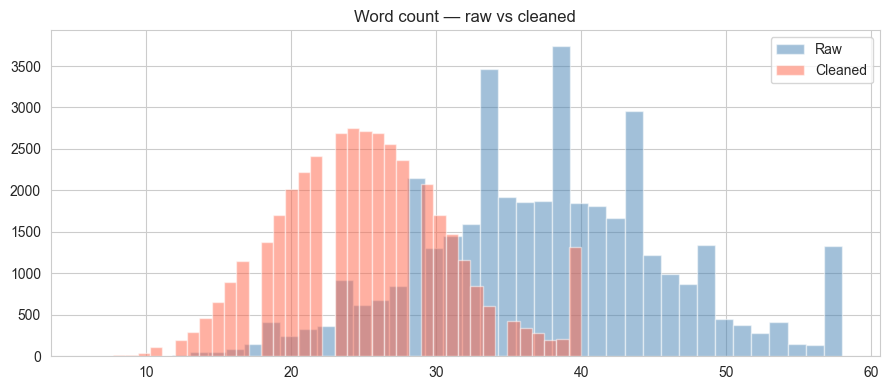

Mean words raw : 37.8
Mean words clean: 25.4


In [6]:
df['raw_words'] = df['content'].astype(str).str.split().str.len()
df['clean_words'] = df['clean_text'].str.split().str.len()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['raw_words'].clip(upper=df['raw_words'].quantile(0.97)), bins=40, alpha=0.5, label='Raw', color='steelblue')
ax.hist(df['clean_words'].clip(upper=df['clean_words'].quantile(0.97)), bins=40, alpha=0.5, label='Cleaned', color='tomato')
ax.set_title('Word count — raw vs cleaned'); ax.legend()
plt.tight_layout(); plt.show()
print('Mean words raw :', round(df['raw_words'].mean(), 1))
print('Mean words clean:', round(df['clean_words'].mean(), 1))

## 6. Encode Label

In [7]:
# Map label to integer codes
df['label'] = df['topic'].astype('category')
label_mapping = dict(enumerate(df['label'].cat.categories))
df['label'] = df['label'].cat.codes
print('Label mapping:', label_mapping)

Label mapping: {0: 'Business', 1: 'Sci-Tech', 2: 'Sports', 3: 'World'}


## 7. Save Cleaned Dataset

In [8]:
out = df[['clean_text', 'label']].copy()
out.to_csv('data/ag_news_cleaned.csv', index=False)
print('Saved -> data/ag_news_cleaned.csv', out.shape)
out.head()

Saved -> data/ag_news_cleaned.csv (40000, 2)


,clean_text,label
0,bbc set major shake claim newspap london briti...,0
1,marsh avert cash crunch embattl insur broker b...,0
2,jeter yanke look take control ap ap derek jete...,2
3,fli sun safeti genesi capsul come back earth s...,1
4,stock seen flat nortel oil weigh new york reut...,0
